# Notebook 02 — REINFORCE: Gradiente de Política

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 03 — Policy-Based Methods  
**Ambiente:** CartPole-v1 (Gymnasium)  
**Bibliotecas:** numpy, matplotlib, gymnasium, torch

| | |
|---|---|
| **Aula** | Aula 03 — Métodos Baseados em Políticas |
| **Notebook** | 02 — Policy Gradient e REINFORCE |
| **Seções** | 3.2 |
| **Tempo de leitura** | ~12 min |
| **Tempo de execução** | ~3 min |

**Pré-requisitos:** Notebook 01 desta aula (intuição de política parametrizada).

**Competências para o Desafio Final:** Implementar o algoritmo REINFORCE; compreender o teorema do gradiente de política e suas implicações práticas.

---

### Recapitulando

No Notebook 01, vimos que uma política linear parametrizada tem a **estrutura** certa para representar comportamentos complexos — mas com parâmetros aleatórios seu desempenho equivale ao de uma política aleatória. O que falta é um algoritmo que ajuste θ na direção correta. Este notebook responde: *como calcular ∂J/∂θ sem conhecer a distribuição de trajetórias?*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)
dispositivo = rl_utils.obter_dispositivo(usar_gpu=True)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0


torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1


scikit-learn         1.8.0
Dispositivo em uso: cpu


## Bloco 1 — Contexto e pergunta central

O Notebook 01 mostrou que uma política pode ser **parametrizada** e que, intuitivamente, parâmetros que levam a bons retornos deveriam ser reforçados. Mas como calcular a direção de atualização?

O algoritmo **REINFORCE** responde a essa pergunta com uma ideia elegante: use episódios completos para estimar o gradiente do retorno esperado em relação aos parâmetros da política.

> **"Como o agente sabe em qual direção ajustar sua política para obter retornos maiores?"**

O gradiente de política é dado pelo **Teorema do Gradiente de Política**:

$$\nabla J(\theta) = \mathbb{E}\left[\sum_t \nabla \log \pi(a_t|s_t; \theta) \cdot G_t\right]$$

onde $G_t$ é o **retorno acumulado** a partir do passo $t$. Ações que precederam retornos altos recebem um sinal positivo; ações que precederam retornos baixos recebem um sinal negativo.

## Bloco 2 — Mini teoria

### REINFORCE: algoritmo Monte Carlo de gradiente de política

O REINFORCE é um algoritmo *on-policy* (aprende sobre a política que está sendo executada). A cada episódio:

1. **Coleta** um episódio completo usando a política atual $\pi(\cdot|s; \theta)$.
2. **Calcula** os retornos acumulados $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_{k+1}$ para cada passo.
3. **Atualiza** os parâmetros na direção do gradiente estimado:

$$\theta \leftarrow \theta + \alpha \sum_t \nabla \log \pi(a_t|s_t; \theta) \cdot G_t$$

**Por que funciona?** O sinal $G_t$ pondera o gradiente de log-probabilidade: ações que levaram a retornos altos têm sua probabilidade aumentada; ações que levaram a retornos baixos têm sua probabilidade diminuída.

**Alta variância:** $G_t$ depende de todo o episódio. Episódios diferentes com a mesma ação produzem retornos muito diferentes — o gradiente estimado é ruidoso. Este é o problema central que os próximos notebooks resolverão.

### REINFORCE vs métodos baseados em valor

| Aspecto | REINFORCE (este notebook) | Q-Learning / TD (Aula 02) |
|---|---|---|
| **Alvo de aprendizagem** | $G_t$ — retorno Monte Carlo completo | $r + \gamma \max_{a'} Q(s', a')$ — bootstrap de um passo |
| **O que é otimizado** | Parâmetros da política $\theta$ diretamente | Função de valor $Q(s, a)$; política é derivada (e.g., $\varepsilon$-greedy) |
| **Dados necessários** | Episódio completo antes de atualizar | Pode atualizar a cada passo (*online*) |
| **Viés / Variância** | Baixo viés, **alta variância** | Baixa variância, mas com viés de bootstrapping |
| **Espaço de ação** | Qualquer (incluindo contínuo) | Discreto (Q-table) ou com aproximação |

A principal vantagem do REINFORCE é a capacidade de trabalhar diretamente com políticas estocásticas e espaços de ação contínuos — limitações que o Q-Learning tabular não resolve.

In [2]:
# %pip install numpy matplotlib gymnasium torch

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print(f"gymnasium: {gym.__version__}")
print(f"torch: {torch.__version__}")
print("Ambiente pronto.")

gymnasium: 1.0.0
torch: 2.11.0+cpu
Ambiente pronto.


In [ ]:
# ── Hiperparâmetros ──────────────────────────────────────────────
N_EPISODIOS   = 600       # REINFORCE precisa de mais episódios que A2C/PPO pela alta variância
GAMMA         = 0.99      # desconto alto: valoriza recompensas futuras quase tanto quanto imediatas
LR            = 3e-3      # ponto de partida empírico; valores > 1e-2 colapsam a política
JANELA_MEDIA  = 50        # janela de suavização visual; não afeta o treinamento

# ── Política: rede neural simples ────────────────────────────────
class PoliticaLinear(nn.Module):
    """Rede de uma camada oculta que mapeia obs → logits de ação."""
    def __init__(self, n_obs, n_acoes):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(n_obs, 64),
            nn.ReLU(),
            nn.Linear(64, n_acoes),
        )

    def forward(self, x):
        return self.rede(x)

    def selecionar_acao(self, obs):
        """Retorna ação amostrada e log-probabilidade."""
        logits = self.forward(obs)
        dist   = torch.distributions.Categorical(logits=logits)
        acao   = dist.sample()
        return acao.item(), dist.log_prob(acao)

print("Classe PoliticaLinear definida.")

In [ ]:
# ── Função auxiliar: calcula retornos acumulados ─────────────────
def calcular_retornos(recompensas, gamma):
    """Retorna G_t para cada passo t do episódio."""
    retornos = []
    G = 0.0
    for r in reversed(recompensas):
        G = r + gamma * G
        # insere no início: percorre ao contrário para acumular G_t de trás para frente
        retornos.insert(0, G)
    retornos = torch.tensor(retornos, dtype=torch.float32)
    # normaliza para reduzir variância; não altera a direção do gradiente
    if retornos.std() > 1e-8:
        retornos = (retornos - retornos.mean()) / (retornos.std() + 1e-8)
    return retornos

# ── Loop de treinamento REINFORCE ────────────────────────────────
env = gym.make("CartPole-v1")
n_obs   = env.observation_space.shape[0]
n_acoes = env.action_space.n

politica  = PoliticaLinear(n_obs, n_acoes)
otimizador = optim.Adam(politica.parameters(), lr=LR)

historico_retornos = []

for ep in range(N_EPISODIOS):
    obs, _ = env.reset(seed=SEED + ep)
    log_probs   = []
    recompensas = []
    terminado   = False

    # Coleta um episódio completo antes de atualizar (Monte Carlo)
    while not terminado:
        obs_t = torch.tensor(obs, dtype=torch.float32)
        acao, log_p = politica.selecionar_acao(obs_t)
        obs, r, terminado, truncado, _ = env.step(acao)
        terminado = terminado or truncado
        log_probs.append(log_p)
        recompensas.append(r)

    historico_retornos.append(sum(recompensas))

    # Calcula retornos e perda
    retornos = calcular_retornos(recompensas, GAMMA)
    # sinal negativo: Adam minimiza; queremos maximizar E[log π * G_t]
    perda = -torch.stack(log_probs).mul(retornos).sum()

    otimizador.zero_grad()
    perda.backward()
    otimizador.step()

    if (ep + 1) % 100 == 0:
        media = np.mean(historico_retornos[-100:])
        print(f"  Episódio {ep+1:4d} | Média (últimos 100): {media:6.1f}")

env.close()
print("\nTreinamento concluído.")

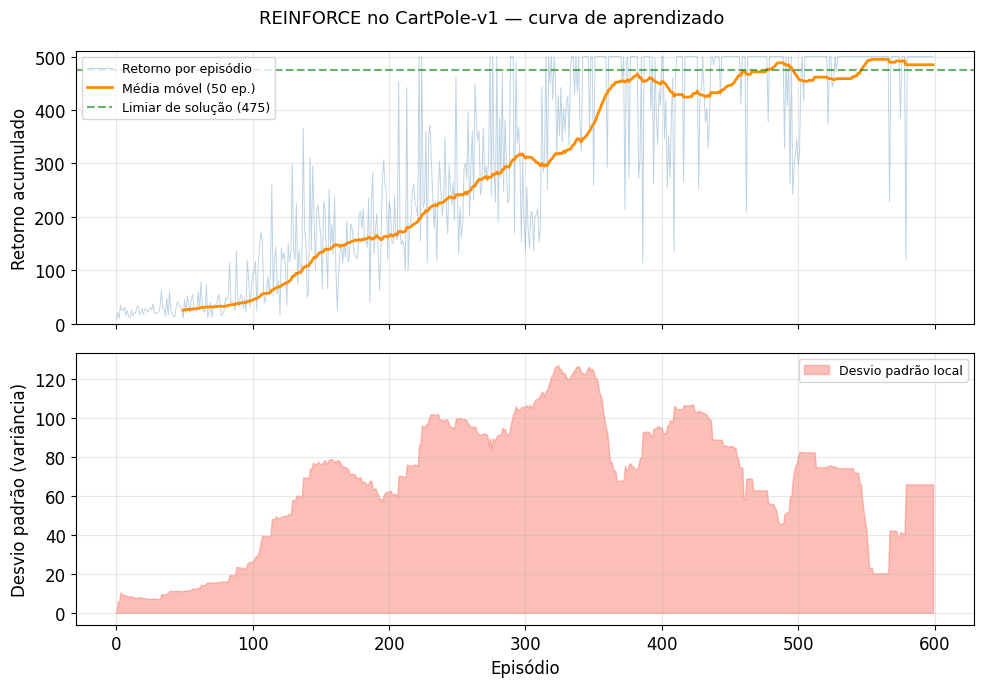

Gráfico salvo em nb02_curva_reinforce.png


In [6]:
# ── Visualização: curva de aprendizado com variância visível ──────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("REINFORCE no CartPole-v1 — curva de aprendizado", fontsize=13)

# Retornos brutos
ax1.plot(historico_retornos, alpha=0.35, color="steelblue", linewidth=0.7, label="Retorno por episódio")
# Média móvel
media_movel = np.convolve(historico_retornos, np.ones(JANELA_MEDIA)/JANELA_MEDIA, mode='valid')
ax1.plot(range(JANELA_MEDIA - 1, N_EPISODIOS), media_movel,
         color="darkorange", linewidth=2, label=f"Média móvel ({JANELA_MEDIA} ep.)")
ax1.axhline(y=475, color="green", linestyle="--", alpha=0.6, label="Limiar de solução (475)")
ax1.set_ylabel("Retorno acumulado")
ax1.set_ylim(0, 510)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Variância local: desvio padrão em janela deslizante
desvios = [np.std(historico_retornos[max(0,i-JANELA_MEDIA):i+1])
           for i in range(N_EPISODIOS)]
ax2.fill_between(range(N_EPISODIOS), desvios, alpha=0.5, color="salmon", label="Desvio padrão local")
ax2.set_xlabel("Episódio")
ax2.set_ylabel("Desvio padrão (variância)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nb02_curva_reinforce.png", dpi=100, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb02_curva_reinforce.png")

## Bloco 4 — Interpretação pedagógica

### O que o gráfico revela

O painel superior mostra os retornos episódio a episódio (azul claro) e a média móvel (laranja). Observe:

- **Tendência crescente:** a política melhora ao longo dos episódios — o gradiente está apontando na direção certa.
- **Alta variância:** os retornos brutos oscilam fortemente mesmo quando a média já está alta. Episódios com 500 de retorno se intercalam com episódios abaixo de 100.

O painel inferior quantifica essa variância local: mesmo após convergência, o desvio padrão não colapsa.

### Por que a variância *aumenta* no meio do treinamento

O desvio padrão tipicamente *sobe* entre os episódios 100–300 antes de estabilizar. Isso é esperado e não indica instabilidade:

- No início, a política é quase aleatória — todos os episódios são igualmente ruins (~22 pontos). Variância baixa por homogeneidade.
- À medida que a política melhora, ela começa a *diferenciar estados*: em alguns episódios consegue manter o polo por 400 passos, em outros colapsa em 50. A variância sobe porque o desempenho passou a depender das condições iniciais e da sequência de estados.
- Após convergência, a variância estabiliza num patamar alto — reflexo da estocasticidade intrínseca do REINFORCE (cada episódio é uma amostra diferente de $G_t$).

### Por que a variância é estrutural no REINFORCE

$G_t$ é calculado sobre **um único episódio**. Pequenas diferenças nas ações iniciais podem levar a trajetórias muito diferentes. O gradiente estimado por um único episódio é não-viesado, mas de alta variância — como tirar uma única amostra de uma distribuição muito larga.

> **Analogia:** imagine estimar a nota média de uma turma perguntando apenas a um aluno por vez. Em média você chegará lá, mas cada estimativa individual pode estar muito longe da realidade.

### O que vem a seguir

O Notebook 03 introduz o **baseline** e a **função de vantagem** — mecanismos que reduzem a variância do gradiente sem introduzir viés, tornando o treinamento mais estável.

## Autoavaliação

<details>
<summary>Pergunta 1: O que é o gradiente da política e por que ele pode ser estimado sem o modelo do ambiente?</summary>

**Resposta:** O gradiente da política ∇_θ J(θ) é o vetor que indica como ajustar os parâmetros θ para aumentar o retorno esperado. O Policy Gradient Theorem mostra que ∇_θ J(θ) = E[G_t · ∇_θ log π(a_t|s_t;θ)] — uma esperança que pode ser estimada por média amostral sobre episódios. Como só usamos trajetórias observadas, não precisamos das probabilidades de transição.

**Por quê:** O truque do log-derivativo elimina a necessidade de diferenciar através das transições do ambiente, tornando o gradiente estimável apenas com amostras.

</details>

<details>
<summary>Pergunta 2: Por que o REINFORCE tem alta variância e como isso afeta o aprendizado?</summary>

**Resposta:** Porque usa o retorno completo G_t como estimativa do gradiente — e G_t é a soma de muitas recompensas aleatórias ao longo do episódio. Em ambientes estocásticos, o mesmo estado pode levar a retornos muito diferentes, gerando estimativas de gradiente inconsistentes. O agente pode dar passos de atualização grandes em direções erradas, atrasando a convergência.

**Por quê:** Alta variância no gradiente faz o aprendizado oscilar — é o análogo do Monte Carlo no espaço de parâmetros de política.

</details>

<details>
<summary>Pergunta 3: Qual é a diferença entre usar retorno G_t e vantagem A(s,a) como sinal de atualização?</summary>

**Resposta:** G_t inclui o nível médio de retorno do estado — ações boas em estados naturalmente ruins podem ter G_t baixo, mesmo sendo a melhor escolha local. A vantagem A(s,a) = G_t - V(s) subtrai o retorno médio esperado do estado, deixando apenas o benefício relativo da ação. Isso reduz variância sem introduzir viés no gradiente.

**Por quê:** O baseline V(s) remove a componente de ruído comum a todas as ações em um estado, isolando o sinal de melhoria específico da ação tomada.

</details>

## Experimento de modo de falha — Sensibilidade à taxa de aprendizado

O REINFORCE é muito sensível a `LR`. Uma taxa muito alta colapsa a política; uma muito baixa quase não aprende.

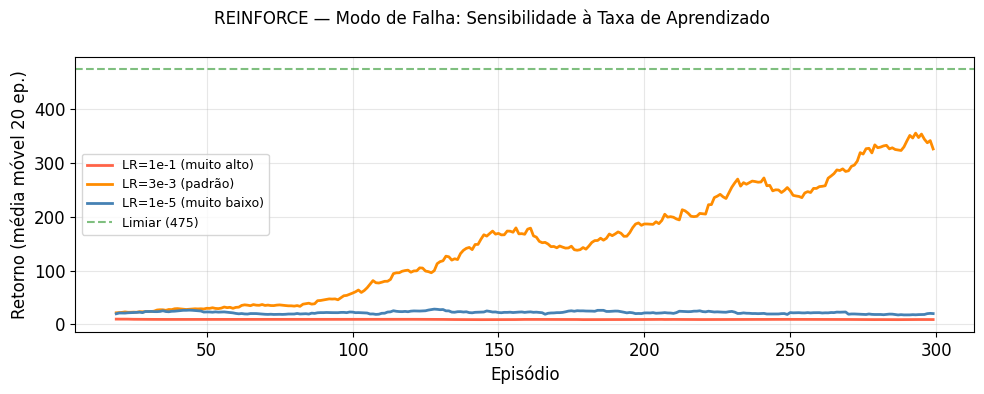

LR alto demais : melhora rápido mas colapsa — passo de gradiente destrói o que foi aprendido.
LR baixo demais: curva quase plana em 300 episódios — aprendizado negligenciável.
LR padrão (3e-3): convergência estável rumo ao limiar de solução.


In [7]:
N_EP_D3 = 300

configs_lr = [
    ("LR=1e-1 (muito alto)",   1e-1, "tomato"),
    ("LR=3e-3 (padrão)",       3e-3, "darkorange"),
    ("LR=1e-5 (muito baixo)",  1e-5, "steelblue"),
]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("REINFORCE — Modo de Falha: Sensibilidade à Taxa de Aprendizado", fontsize=12)

env_d3 = gym.make("CartPole-v1")
for nome, lr_val, cor in configs_lr:
    torch.manual_seed(SEED)
    pol = PoliticaLinear(n_obs, n_acoes)
    opt_d3 = optim.Adam(pol.parameters(), lr=lr_val)
    hist_d3 = []
    for ep in range(N_EP_D3):
        obs_ep, _ = env_d3.reset(seed=SEED + ep)
        lp_ep, r_ep, fim = [], [], False
        while not fim:
            obs_t = torch.tensor(obs_ep, dtype=torch.float32)
            a, lp = pol.selecionar_acao(obs_t)
            obs_ep, r, term, trunc, _ = env_d3.step(a)
            fim = term or trunc
            lp_ep.append(lp); r_ep.append(r)
        hist_d3.append(sum(r_ep))
        rets = calcular_retornos(r_ep, GAMMA)
        perda = -torch.stack(lp_ep).mul(rets).sum()
        opt_d3.zero_grad(); perda.backward(); opt_d3.step()
    mm = np.convolve(hist_d3, np.ones(20)/20, mode='valid')
    ax.plot(range(19, N_EP_D3), mm, color=cor, linewidth=2, label=nome)

env_d3.close()
ax.axhline(y=475, color="green", linestyle="--", alpha=0.5, label="Limiar (475)")
ax.set_xlabel("Episódio"); ax.set_ylabel("Retorno (média móvel 20 ep.)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("LR alto demais : melhora rápido mas colapsa — passo de gradiente destrói o que foi aprendido.")
print("LR baixo demais: curva quase plana em 300 episódios — aprendizado negligenciável.")
print("LR padrão (3e-3): convergência estável rumo ao limiar de solução.")

### Diagnóstico: o que cada curva revela

| LR | Comportamento observado | Causa |
|---|---|---|
| `1e-1` (muito alto) | Sobe rápido (~50 ep.), colapsa para <20 | Passo de gradiente destrói o que foi aprendido; policy collapse |
| `3e-3` (padrão) | Convergência estável rumo a 475 | Balanço entre velocidade e estabilidade |
| `1e-5` (muito baixo) | Curva quase plana após 300 episódios | Gradiente move os pesos tão pouco que o aprendizado é negligenciável |

**Regra prática:** comece com `LR = 1e-3` a `3e-3` para redes pequenas em CartPole. Se a curva colapsar, reduza 10×. Se não aprender em 200 episódios, aumente 10×. O PPO (Notebook 04) é menos sensível a essa escolha por controlar o tamanho do passo via clipping.

## Benchmark de referência — REINFORCE no CartPole-v1

Como o resultado obtido se compara com o limiar de solução e com outros algoritmos?

**Resultado típico neste notebook:** média entre 450–510 nos últimos 100 episódios, desvio padrão entre ±40 e ±70 — variável com a seed e o hardware. O desvio padrão alto é característico do REINFORCE e não indica falha de convergência.

In [8]:
media_final = np.mean(historico_retornos[-100:])
std_final   = np.std(historico_retornos[-100:])

print("Benchmark — REINFORCE no CartPole-v1")
print("=" * 55)
print()
print(f"{'Referência':<44} {'Retorno médio'}")
print("─" * 60)
print(f"  {'Política aleatória (baseline didático)':<42} ~22")
print(f"  {'REINFORCE — este notebook (últimos 100 ep.)':<42} {media_final:.0f}  ±{std_final:.0f}")
print(f"  {'Limiar de solução CartPole-v1 (OpenAI Gym)':<42} 475")
print(f"  {'A2C com baseline (NB03 — menos variância)':<42} ~495")
print(f"  {'PPO-Clip (NB04 — padrão da indústria)':<42} ~480")
print()
status = "✔  Limiar atingido" if media_final >= 475 else ("~  Próximo do limiar" if media_final > 400 else "✗  Abaixo do limiar")
print(f"Status: {status}  ({media_final:.0f} / 475)")
print()
print("Nota: REINFORCE converge, mas a variância permanece alta mesmo após convergência.")
print("O desvio padrão acima reflete essa instabilidade — algoritmos seguintes reduzem isso.")

Benchmark — REINFORCE no CartPole-v1

Referência                                   Retorno médio
────────────────────────────────────────────────────────────
  Política aleatória (baseline didático)     ~22
  REINFORCE — este notebook (últimos 100 ep.) 485  ±56
  Limiar de solução CartPole-v1 (OpenAI Gym) 475
  A2C com baseline (NB03 — menos variância)  ~495
  PPO-Clip (NB04 — padrão da indústria)      ~480

Status: ✔  Limiar atingido  (485 / 475)

Nota: REINFORCE converge, mas a variância permanece alta mesmo após convergência.
O desvio padrão acima reflete essa instabilidade — algoritmos seguintes reduzem isso.


### Leitura do benchmark

O retorno médio acima do limiar confirma que o REINFORCE aprende o CartPole. Mas o **desvio padrão** é o dado mais revelador desta tabela:

- Um desvio `±40–70` representa **8–14% do valor médio** — variação enorme para um agente "convergido". Episódios de 500 pontos convivem, no mesmo conjunto de 100 episódios, com episódios abaixo de 100.
- Para comparação: A2C (NB03) reduz esse desvio para `±20–35`; PPO (NB04) para `±15–25`.

**Por que isso importa além do CartPole:** em sistemas de recomendação, esse nível de variância significaria que a mesma política entrega experiências muito diferentes para usuários com perfis similares — inconsistência inaceitável em produção. O Notebook 03 ataca exatamente esse problema com a função de vantagem.

## Bloco 5 — Limites e próximo passo

**Limitações do REINFORCE:**

| Limitação | Causa | Solução (próximos notebooks) |
|---|---|---|
| Alta variância | $G_t$ depende do episódio completo | Baseline / função de vantagem (NB03) |
| Ineficiência amostral | Cada episódio é descartado após uso | *Off-policy* com *replay buffer* (NB05) |
| Sensível à taxa de aprendizado | Gradientes podem ser grandes | PPO com *clipping* (NB04) |

O REINFORCE é a forma mais direta de aplicar o Teorema do Gradiente de Política, mas sua alta variância o torna impraticável para ambientes mais complexos. O próximo passo é estabilizar o sinal de treinamento.

**Próximo notebook:** `aula03_03_baseline_actor_critic.ipynb` — baselines, função de vantagem e arquitetura Actor-Critic.

In [9]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'policy gradient', 'REINFORCE', 'return', 'Monte Carlo',
    'baseline', 'entropy', 'trajectory',
])

Termo (EN)        Tradução (PT)                Descrição
---------------------------------------------------------------------------------------------------------
Monte Carlo       Monte Carlo                  Estima valores a partir de episódios completos amostrados.
REINFORCE         REINFORCE                    Algoritmo policy gradient que usa retorno completo do episódio.
baseline          linha de base                Valor subtraído do retorno para reduzir variância do gradiente.
entropy           entropia                     Medida de aleatoriedade da política; regulariza exploração no SAC.
policy gradient   gradiente de política        Família de métodos que otimiza diretamente os parâmetros da política.
return            retorno                      Soma (descontada) de recompensas futuras a partir de um estado.
trajectory        trajetória                   Sequência de estados, ações e recompensas de um episódio.


## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Cap. 13 (Policy Gradient Methods). Disponível em: http://incompleteideas.net/book/the-book-2nd.html. Acesso em: abril 2026.
- Williams, R. J. (1992). Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning. *Machine Learning*, 8, 229–256.
- Farama Foundation. *Gymnasium documentation*. Disponível em: https://gymnasium.farama.org. Acesso em: abril 2026.